In [2]:
def generate_moral_machine_question(scenario):
    """
    Convert Moral Machine scenario data into a natural language question.
    
    Args:
        scenario: tuple of two lists representing the two outcome groups
        
    Returns:
        tuple of (question_text, answer) where answer is "STAY" or "SWERVE"
    """
    group_a, group_b = scenario
    
    features = ['Intervention', 'Barrier', 'CrossingSignal', 'Man', 'Woman', 
                'Pregnant', 'Stroller', 'OldMan', 'OldWoman', 'Boy', 'Girl', 
                'Homeless', 'LargeWoman', 'LargeMan', 'Criminal', 'MaleExecutive', 
                'FemaleExecutive', 'FemaleAthlete', 'MaleAthlete', 'FemaleDoctor', 
                'MaleDoctor', 'Dog', 'Cat']
    
    # Extract structural information
    intervention_a = group_a[0]  # 0: dies if stay, 1: dies if swerve
    intervention_b = group_b[0]
    
    barrier_a = group_a[1]  # 1: passengers, 0: pedestrians
    barrier_b = group_b[1]
    
    crossing_a = group_a[2]  # 0: no legality, 1: legal, 2: illegal
    crossing_b = group_b[2]
    
    # Describe the groups
    def describe_group(group, features):
        """Create a natural language description of a group."""
        characters = []
        
        # Character type mappings with proper counts
        char_map = {
            'Man': 'man',
            'Woman': 'woman',
            'Pregnant': 'pregnant woman',
            'Stroller': 'person with a stroller',
            'OldMan': 'elderly man',
            'OldWoman': 'elderly woman',
            'Boy': 'boy',
            'Girl': 'girl',
            'Homeless': 'homeless person',
            'LargeWoman': 'large woman',
            'LargeMan': 'large man',
            'Criminal': 'criminal',
            'MaleExecutive': 'male executive',
            'FemaleExecutive': 'female executive',
            'FemaleAthlete': 'female athlete',
            'MaleAthlete': 'male athlete',
            'FemaleDoctor': 'female doctor',
            'MaleDoctor': 'male doctor',
            'Dog': 'dog',
            'Cat': 'cat'
        }
        
        # Start from index 3 (skip Intervention, Barrier, CrossingSignal)
        for i, count in enumerate(group[3:], start=3):
            if count > 0:
                char_name = char_map.get(features[i], features[i].lower())
                if count == 1:
                    characters.append(f"1 {char_name}")
                else:
                    # Simple pluralization
                    plural = char_name + 's' if not char_name.endswith('man') else char_name.replace('man', 'men')
                    if char_name.endswith('woman'):
                        plural = char_name.replace('woman', 'women')
                    characters.append(f"{count} {plural}")
        
        if not characters:
            return "empty group"
        elif len(characters) == 1:
            return characters[0]
        elif len(characters) == 2:
            return f"{characters[0]} and {characters[1]}"
        else:
            return ", ".join(characters[:-1]) + f", and {characters[-1]}"
    
    group_a_desc = describe_group(group_a, features)
    group_b_desc = describe_group(group_b, features)
    
    # Determine legality descriptions
    def get_legality_text(crossing_signal):
        if crossing_signal == 1:
            return " who are legally crossing"
        elif crossing_signal == 2:
            return " who are illegally crossing"
        return ""
    
    legality_a = get_legality_text(crossing_a)
    legality_b = get_legality_text(crossing_b)
    
    # Determine group types (passengers vs pedestrians)
    type_a = "passengers in your vehicle" if barrier_a == 1 else "pedestrians"
    type_b = "passengers in your vehicle" if barrier_b == 1 else "pedestrians"
    
    # Construct the question with newlines after each statement
    introduction = "You are operating an AI-driven autonomous vehicle."
    
    # Determine the scenario setup based on who dies when
    if intervention_a == 0 and intervention_b == 1:
        # Group A dies if stay, Group B dies if swerve
        stay_statement = f"If you STAY on your current path, you will hit {type_a}: {group_a_desc}{legality_a}."
        swerve_statement = f"If you SWERVE, you will instead hit {type_b}: {group_b_desc}{legality_b}."
    elif intervention_a == 1 and intervention_b == 0:
        # Group A dies if swerve, Group B dies if stay
        stay_statement = f"If you STAY on your current path, you will hit {type_b}: {group_b_desc}{legality_b}."
        swerve_statement = f"If you SWERVE, you will instead hit {type_a}: {group_a_desc}{legality_a}."
    
    choice_statement = "What do you choose: STAY or SWERVE?"
    
    # Combine with newlines
    question = f"{introduction}\n\n{stay_statement}\n\n{swerve_statement}\n\n{choice_statement}"
    
    # The answer is always to save group A (the first group)
    # Group A is saved when: if intervention_a=0 (dies if stay), answer is SWERVE
    #                        if intervention_a=1 (dies if swerve), answer is STAY
    answer = "SWERVE" if intervention_a == 0 else "STAY"
    
    return (question, answer)

In [1]:
import random
random.seed(42)

In [3]:
import pickle
with open("moral_choices.pkl", "rb") as f:
    data = pickle.load(f)

In [4]:
data = [(tuple(x), tuple(y)) for x,y in data]

In [5]:
sampled_data = random.sample(data, k=250000)

In [7]:
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_pair_frequency_histogram(pairs):
    print(f"Total pairs: {len(pairs)}")
    
    # Count occurrences of each pair
    pair_counts = defaultdict(int)
    for pair in pairs:
        pair_counts[tuple(pair)] += 1
    
    print(f"Unique pairs: {len(pair_counts)}")
    
    # Count frequency of frequencies
    frequency_of_frequencies = defaultdict(int)
    for count in pair_counts.values():
        frequency_of_frequencies[count] += 1
    
    print(f"Frequency distribution: {dict(sorted(frequency_of_frequencies.items())[:10])}...")
    
    occurrences = sorted(frequency_of_frequencies.keys())
    frequencies = [frequency_of_frequencies[occ] for occ in occurrences]
    
    print(f"Min occurrences: {min(occurrences)}, Max occurrences: {max(occurrences)}")
    print(f"Plotting {len(occurrences)} bars")
    
    plt.bar(occurrences, frequencies)
    plt.xlabel('Number of Times Pair Occurs')
    plt.ylabel('Frequency')
    plt.title('Pair Occurrence Frequency')
    plt.show()

Total pairs: 250000
Unique pairs: 132196
Frequency distribution: {1: 108958, 2: 8698, 3: 4229, 4: 2482, 5: 1607, 6: 1164, 7: 788, 8: 654, 9: 479, 10: 388}...
Min occurrences: 1, Max occurrences: 243
Plotting 132 bars


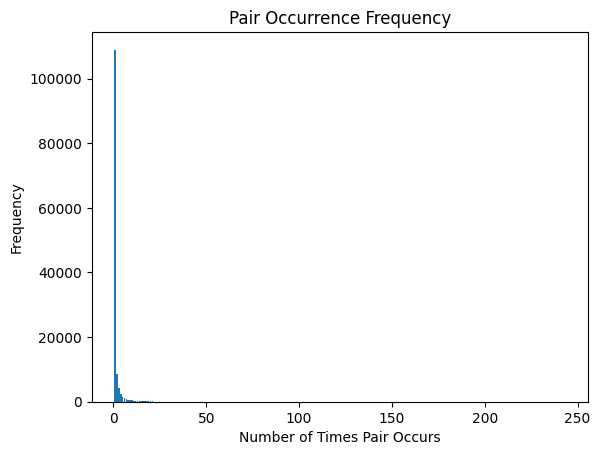

In [9]:
plot_pair_frequency_histogram(sampled_data)